# Cycle 02 results: WT1/HLA-A*02:01 de novo minibinder design

Companion to `docs/narrative.md`. This notebook is the evidence layer: real numbers, plots, the hero design.

Read narrative sections 1 through 5 first if you haven't; this notebook assumes you know the controls panel, the iPAE/ipLDDT metrics, and the cycle 1 calibration shape.

Cycle 02 ran end-to-end with deliberately naive priors: 8 hotspots, no peptide-centric arcing, no alanine bias on ProteinMPNN. Verdict: HALT at fraction_pass_intermediate = 0.02 (threshold 0.10). One design crossed the strict cuts. The shape of the distribution is the more useful part.


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Cycle 1 control reference (A100 baseline)
cycle1 = pd.DataFrame([
    {"id": "P1", "ipae": 4.88, "iplddt": 94.5, "bsa": 2692, "kind": "positive"},
    {"id": "P2", "ipae": 4.56, "iplddt": 95.9, "bsa": 2788, "kind": "positive"},
    {"id": "P3", "ipae": 4.54, "iplddt": 94.2, "bsa": 2698, "kind": "positive_wrong_target"},
    {"id": "N1", "ipae": 24.72, "iplddt": 34.5, "bsa": 1524, "kind": "negative"},
    {"id": "N2", "ipae": 25.70, "iplddt": 31.4, "bsa": 2153, "kind": "negative"},
])

# Cycle 02 Stage 1 aggregates
stage1 = dict(
    designs_attempted=200,
    geometry_pass=26,
    fail_insufficient_contacts=173,
    fail_internal_clash=4,
    zero_hotspot_contact=131,
    motif_rmsd_median=0.12,
    binder_length_median=89,
    wall_time_h=1.0,
)

# Cycle 02 Stage 2 aggregates
stage2 = dict(
    candidates_total=104,
    fan_in_top_n=50,
    strict_cut_pass=1,
    ipae_min=6.41, ipae_p25=20.41, ipae_median=22.66, ipae_p75=24.06, ipae_max=26.17,
    iplddt_min=54.95, iplddt_max=91.07,
    wall_time_h=6.0,
)

# Stage 2 iPAE histogram (5 Å bins)
stage2_ipae_hist = [
    (5, 10, 1),    # hero
    (10, 15, 1),
    (15, 20, 10),
    (20, 25, 35),  # negative-control zone
    (25, 30, 3),
]

# Hero design
hero = dict(
    id="design_2079_seq00",
    length=99,
    topology="4-helix bundle",
    ipae=6.41,
    iplddt=91.07,
    bsa=976,
    sequence="AAAEKAKEAAKKFKEAAKIAAEKGAEAGIKAIREIGKELLAAAATPAMEALGKAALAAAAAIAAELAAFPERAAEITKRTVAAAKELAKAAEEVAKALK",
)

# Backbone 2079: all 4 ProteinMPNN sequences scored
backbone_2079 = pd.DataFrame([
    {"seq_id": 0, "ipae": 6.41,  "iplddt": 91.07, "bsa": 976.5, "verdict": "pass"},
    {"seq_id": 2, "ipae": 19.26, "iplddt": 81.19, "bsa": 1079.5, "verdict": "fail (mis-docked)"},
    {"seq_id": 1, "ipae": 24.11, "iplddt": 80.86, "bsa": 723.6, "verdict": "fail (negative zone)"},
    {"seq_id": 3, "ipae": 24.93, "iplddt": 79.69, "bsa": 617.1, "verdict": "fail (negative zone)"},
])

print(f"cycle 1 controls loaded: {len(cycle1)} entries")
print(f"stage 1 geometry yield: {stage1['geometry_pass']}/{stage1['designs_attempted']} = {stage1['geometry_pass']/stage1['designs_attempted']:.1%}")
print(f"stage 2 strict-cut yield: {stage2['strict_cut_pass']}/{stage2['fan_in_top_n']} = {stage2['strict_cut_pass']/stage2['fan_in_top_n']:.1%}")
print(f"hero: {hero['id']} (iPAE {hero['ipae']} Å, ipLDDT {hero['iplddt']:.1f}, BSA {hero['bsa']} Å²)")


cycle 1 controls loaded: 5 entries
stage 1 geometry yield: 26/200 = 13.0%
stage 2 strict-cut yield: 1/50 = 2.0%
hero: design_2079_seq00 (iPAE 6.41 Å, ipLDDT 91.1, BSA 976 Å²)


## The funnel

200 candidate backbones to 1 strict-cut pass. Every gate fired correctly; the failure-mode distribution at each stage is interpretable against the literature.


stage 1 geometry pass: 13.0%
stage 2 strict-cut pass: 2.0% (relative to top-50 fan-in)


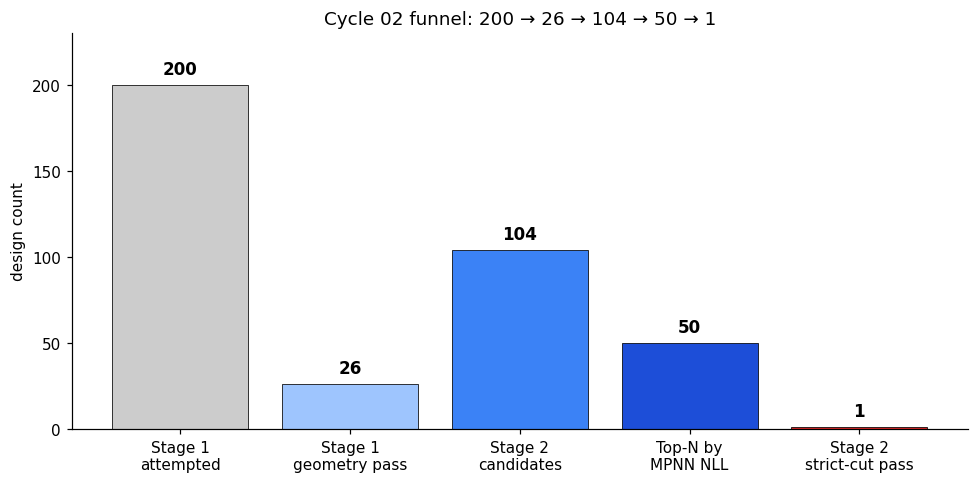

In [2]:
fig, ax = plt.subplots(figsize=(9, 4.5))

stages = ["Stage 1\nattempted", "Stage 1\ngeometry pass", "Stage 2\ncandidates", "Top-N by\nMPNN NLL", "Stage 2\nstrict-cut pass"]
counts = [200, 26, 104, 50, 1]
colors = ["#cccccc", "#9ec5fe", "#3b82f6", "#1d4ed8", "#dc2626"]

bars = ax.bar(stages, counts, color=colors, edgecolor="black", linewidth=0.5)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4, str(count),
            ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_ylabel("design count")
ax.set_title("Cycle 02 funnel: 200 → 26 → 104 → 50 → 1")
ax.set_ylim(0, 230)
plt.tight_layout()
plt.show()

print(f"stage 1 geometry pass: {26/200:.1%}")
print(f"stage 2 strict-cut pass: {1/50:.1%} (relative to top-50 fan-in)")


## Cycle 1 control reference

The frame against which cycle 02 designs are read. Positives in 4.5 to 4.9 Å iPAE, negatives in 24.7 to 25.7. The ipLDDT gap (60 points) is sharper than the iPAE gap (20 Å).

A BSA caveat: the cycle 1 positives are full TCRs (~2700 Å²); minibinders sit at 800 to 1200 Å² per Liu et al. The hero's BSA of 976 Å² is in the minibinder range, not a regression from the TCR controls.


In [3]:
cycle1[["id", "ipae", "iplddt", "bsa", "kind"]]


id,ipae,iplddt,bsa,kind
P1,4.88,94.5,2692,positive
P2,4.56,95.9,2788,positive
P3,4.54,94.2,2698,positive_wrong_target
N1,24.72,34.5,1524,negative
N2,25.70,31.4,2153,negative


## Stage 1: RFdiffusion backbones

200 backbones generated in ~1 hour on a single A100 SXM 80GB. Motif RMSD landed at ~0.12 Å median, well inside the 0.25 Å threshold. The model preserved the pMHC scaffold geometry; the backbones themselves are valid.

The geometry gate passed 26 of 200 (13%). The failure mode is what matters:


99% of Stage 1 failures are insufficient hotspot contacts.
66% of all 200 designs had zero CA contacts to any hotspot (131/200).
This is a placement deficit, not a backbone-quality deficit.


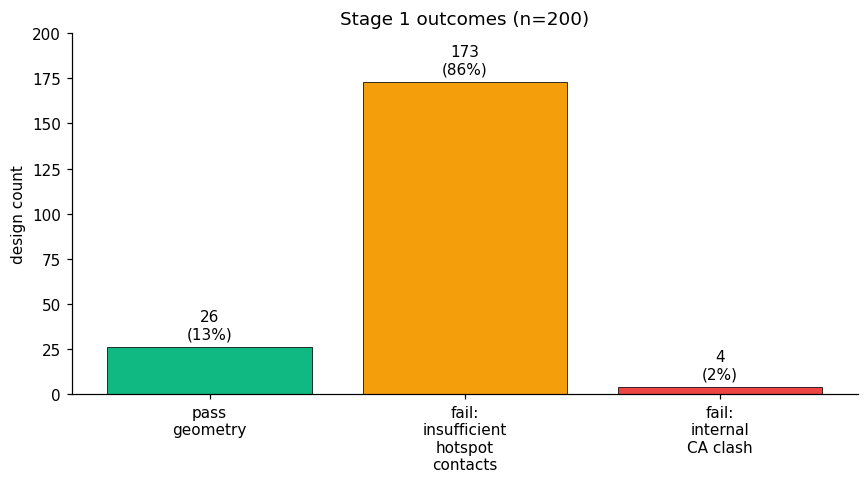

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))

categories = ["pass\ngeometry", "fail:\ninsufficient\nhotspot\ncontacts", "fail:\ninternal\nCA clash"]
values = [stage1["geometry_pass"], stage1["fail_insufficient_contacts"], stage1["fail_internal_clash"]]
colors = ["#10b981", "#f59e0b", "#ef4444"]

bars = ax.bar(categories, values, color=colors, edgecolor="black", linewidth=0.5)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, f"{v}\n({v/200:.0%})",
            ha="center", va="bottom", fontsize=10)

ax.set_ylabel("design count")
ax.set_title("Stage 1 outcomes (n=200)")
ax.set_ylim(0, 200)
plt.tight_layout()
plt.show()

print(f"99% of Stage 1 failures are insufficient hotspot contacts.")
print(f"66% of all 200 designs had zero CA contacts to any hotspot ({stage1['zero_hotspot_contact']}/200).")
print(f"This is a placement deficit, not a backbone-quality deficit.")


### The placement deficit

131 of 200 designs (66%) had zero CA atoms within contact distance of any hotspot. The binders are coherent objects with valid backbones — they're just landing on the wrong face of HLA. Most likely the α3 domain (the larger non-groove surface that contacts β2m), not the α1/α2 peptide-binding cleft.

With only 8 hotspots and the default 10 Å recenter radius, the spatial prior is too weak to constrain placement to the groove. Liu et al. (2025) use 10–15 hotspots plus peptide-centric arcing and report 20–35% Stage 1 yield on similar pMHC-I targets. Our 13% is at the upper end of the unconstrained pre-optimization range they report. Predicted and accepted as a calibration outcome.

The fix for cycle 03 is intervention 1: densify hotspots and switch to peptide-centric arcing.


## Stage 2: ProteinMPNN + AF2-multimer

26 backbones × 4 sequences per backbone = 104 candidates. Top 50 by MPNN NLL went to AF2-multimer folding. ~6 hours wall on A100, dominated by per-design ColabFold MSA server queries.


median iPAE: 22.66 Å (essentially negative-control-equivalent)
70% of designs (35/50) sit in the 20-25 Å range, same range as the cycle 1 negatives
1 design at 6.41 Å, 1.5 Å above the cycle 1 positive band ceiling


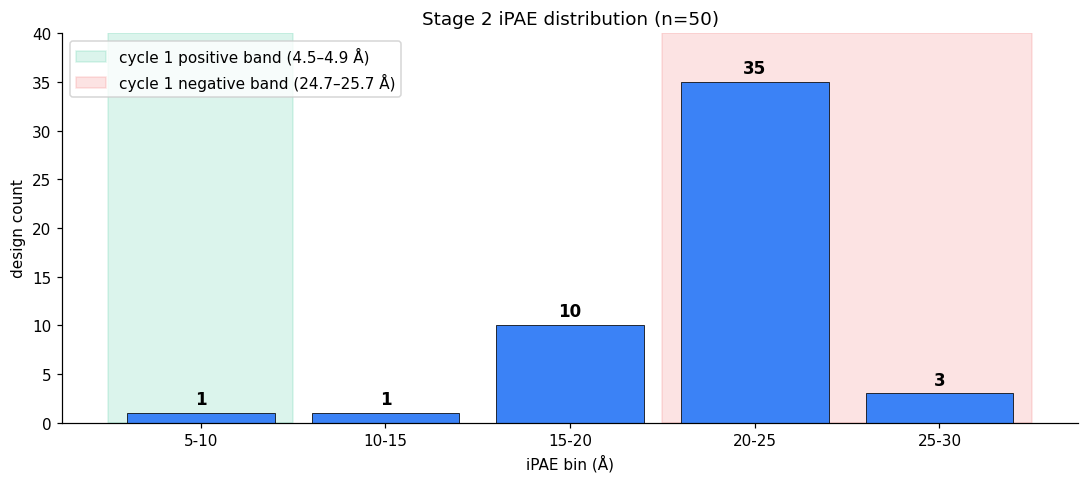

In [5]:
# iPAE distribution across the 50 folded designs
bins = stage2_ipae_hist
labels = [f"{lo}-{hi}" for lo, hi, n in bins]
counts = [n for lo, hi, n in bins]

fig, ax = plt.subplots(figsize=(10, 4.5))

# cycle 1 reference bands as background
ax.axvspan(-0.5, 0.5, alpha=0.15, color="#10b981", label="cycle 1 positive band (4.5–4.9 Å)")
ax.axvspan(2.5, 4.5, alpha=0.15, color="#ef4444", label="cycle 1 negative band (24.7–25.7 Å)")

bars = ax.bar(labels, counts, color="#3b82f6", edgecolor="black", linewidth=0.5)
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(c),
            ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_xlabel("iPAE bin (Å)")
ax.set_ylabel("design count")
ax.set_title(f"Stage 2 iPAE distribution (n={sum(counts)})")
ax.legend(loc="upper left")
ax.set_ylim(0, 40)
plt.tight_layout()
plt.show()

print(f"median iPAE: {stage2['ipae_median']} Å (essentially negative-control-equivalent)")
print(f"70% of designs (35/50) sit in the 20-25 Å range, same range as the cycle 1 negatives")
print(f"1 design at 6.41 Å, 1.5 Å above the cycle 1 positive band ceiling")


### Reading the distribution

The bulk of cycle 02 sits in the negative-control iPAE zone. AF2 is reading these designs as docked-but-wrong-face: coherent objects that aren't engaging the peptide groove with confidence. This is the direct downstream readout of the Stage 1 placement deficit — ProteinMPNN can't repair a backbone that's placed against α3 or β2m.

A diagnostic worth surfacing: several cycle 02 designs scored global pLDDT > 91 and ipTM > 0.74 yet failed the iPAE/ipLDDT cuts entirely. The binders fold well as isolated 4-helix bundles but don't engage the binding cleft. Global pLDDT is dominated by the rigid HLA scaffold (275 aa, well-represented in AF2's training data); ipTM is biased upward by the static A↔B↔C interfaces. **Interface-restricted iPAE and ipLDDT are the correct readout** for this kind of system, consistent with Johansen et al. (2025).


## The hero: design_2079_seq00

The one design that crossed the strict cuts (iPAE ≤ 12 Å AND ipLDDT ≥ 88).


In [6]:
hero_df = pd.DataFrame([
    {"property": "ID", "value": hero["id"], "reference": ""},
    {"property": "length", "value": f"{hero['length']} aa", "reference": "within 70-110 contig"},
    {"property": "topology", "value": hero["topology"], "reference": "consistent with Householder et al. α-helical TCR mimic class"},
    {"property": "iPAE", "value": f"{hero['ipae']} Å", "reference": "1.5 Å above cycle 1 positive ceiling (4.88 Å); 18 Å below negative floor"},
    {"property": "ipLDDT", "value": f"{hero['iplddt']}", "reference": "3 units above strict cut of 88"},
    {"property": "BSA", "value": f"{hero['bsa']} Å²", "reference": "within Liu et al. minibinder range (800-1200 Å²)"},
])
hero_df


property,value,reference
ID,design_2079_seq00,
length,99 aa,within 70-110 contig
topology,4-helix bundle,consistent with Householder et al. α-helical TCR mimic class
iPAE,6.41 Å,1.5 Å above cycle 1 positive ceiling (4.88 Å); 18 Å below negative floor
ipLDDT,91.07,3 units above strict cut of 88
BSA,976 Å²,within Liu et al. minibinder range (800-1200 Å²)


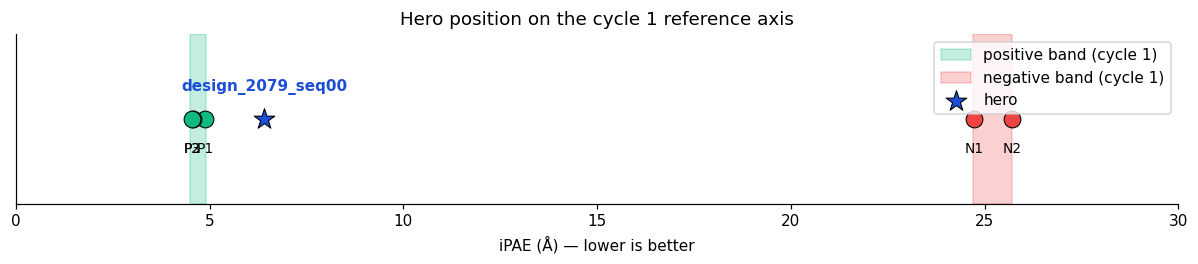

In [7]:
# Position on the cycle 1 reference axis
fig, ax = plt.subplots(figsize=(11, 2.5))

# cycle 1 bands
ax.axvspan(4.5, 4.9, alpha=0.25, color="#10b981", label="positive band (cycle 1)")
ax.axvspan(24.7, 25.7, alpha=0.25, color="#ef4444", label="negative band (cycle 1)")

# controls
for _, c in cycle1.iterrows():
    ax.scatter(c["ipae"], 0, s=120, color="#10b981" if "positive" in c["kind"] else "#ef4444",
               edgecolor="black", linewidth=0.7, zorder=5)
    ax.annotate(c["id"], (c["ipae"], 0), xytext=(0, -22), textcoords="offset points",
                ha="center", fontsize=9)

# hero
ax.scatter(hero["ipae"], 0, s=200, marker="*", color="#1d4ed8", edgecolor="black", linewidth=0.7, zorder=6, label="hero")
ax.annotate(hero["id"], (hero["ipae"], 0), xytext=(0, 18), textcoords="offset points",
            ha="center", fontsize=10, fontweight="bold", color="#1d4ed8")

ax.set_xlim(0, 30)
ax.set_xlabel("iPAE (Å) — lower is better")
ax.set_yticks([])
ax.set_title("Hero position on the cycle 1 reference axis")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


## Backbone 2079 is a sequence-design lottery win

Important caveat for cycle 03 decisions. All four ProteinMPNN sequences on this backbone:


In [8]:
backbone_2079


seq_id,ipae,iplddt,bsa,verdict
0,6.41,91.07,976.5,pass
2,19.26,81.19,1079.5,fail (mis-docked)
1,24.11,80.86,723.6,fail (negative zone)
3,24.93,79.69,617.1,fail (negative zone)


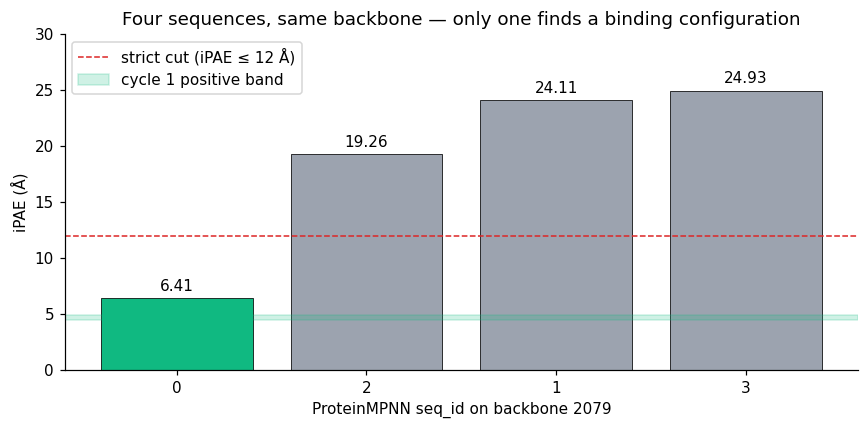

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))

colors = ["#10b981" if v == "pass" else "#9ca3af" for v in backbone_2079["verdict"]]
bars = ax.bar(backbone_2079["seq_id"].astype(str), backbone_2079["ipae"], color=colors, edgecolor="black", linewidth=0.5)
for bar, ipae in zip(bars, backbone_2079["ipae"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4, f"{ipae:.2f}",
            ha="center", va="bottom", fontsize=10)

ax.axhline(12, color="#dc2626", linestyle="--", linewidth=1, label="strict cut (iPAE ≤ 12 Å)")
ax.axhspan(4.5, 4.9, alpha=0.2, color="#10b981", label="cycle 1 positive band")

ax.set_xlabel("ProteinMPNN seq_id on backbone 2079")
ax.set_ylabel("iPAE (Å)")
ax.set_title("Four sequences, same backbone — only one finds a binding configuration")
ax.legend()
ax.set_ylim(0, 30)
plt.tight_layout()
plt.show()


A robust scaffold would produce a tight cluster of passing sequences because the backbone geometry, not the sequence, determines docking. Here three of four sequences on backbone 2079 sit in the 19-25 Å iPAE range — the negative-control zone — and only one happens to find a configuration AF2 reads as binder-like.

This means cycle 02's win was partly stochastic. ProteinMPNN sampled enough sequence space to land on a working solution; the backbone itself permits binding but doesn't enforce it. The cycle 03 fix is intervention 3: increase `num_seq_per_target` from 4 to 8 so a genuinely-viable backbone produces 2-3 redundant passes by Poisson approximation, rather than 1 out of 4 by luck.


## Hero sequence composition: the alanine regularizer trap

The hero sequence is 40.4% alanine. This is the textbook unconstrained ProteinMPNN output: alanine for helix propensity, balanced K/E for surface electrostatics, sparse hydrophobics for core packing, zero cysteine (clean, no disulfide accidents).

AF2 doesn't penalize this — the structural confidence is in the positive zone. But the experimental tractability is hurt: low complexity raises aggregation risk in *E. coli* expression and yeast display, zero W and Y means no UV/A280 quantitation handle and no native fluorescence for binding assays. Both Liu et al. and Householder et al. explicitly bias against alanine during ProteinMPNN sampling for this reason. Cycle 02 did not.



A + K + E account for 69/99 = 70% of the sequence.
Missing residues entirely: W, Y, C, H, N, Q, S, D (8 of 20 canonical residues).


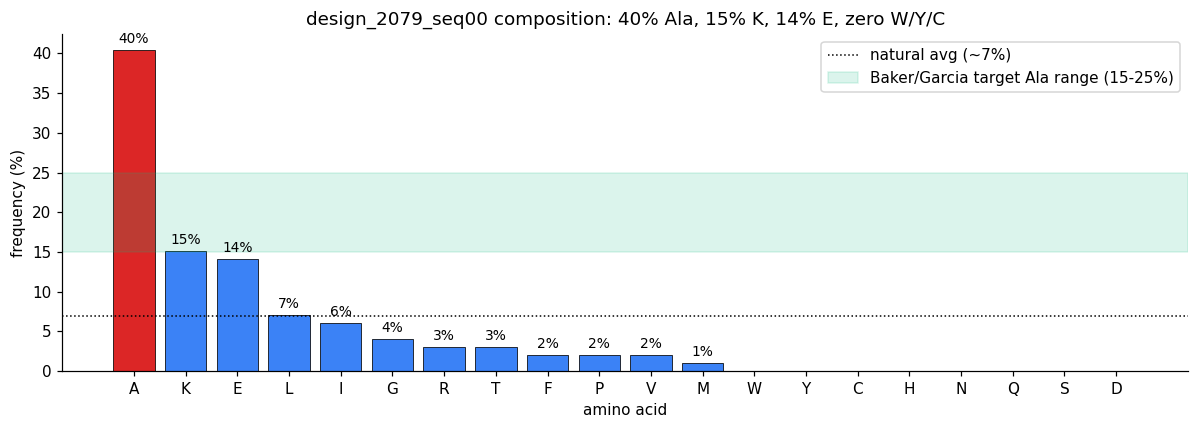

In [10]:
# AA composition of hero
from collections import Counter

counts = Counter(hero["sequence"])
total = len(hero["sequence"])

aa_order = "AKELIGRTFPVMWYCHNQSD"  # high-to-low expected frequency for this sequence
composition = pd.DataFrame([
    {"aa": aa, "count": counts.get(aa, 0), "pct": 100 * counts.get(aa, 0) / total}
    for aa in aa_order
])

fig, ax = plt.subplots(figsize=(11, 4))
colors = ["#dc2626" if aa == "A" else "#3b82f6" for aa in composition["aa"]]
bars = ax.bar(composition["aa"], composition["pct"], color=colors, edgecolor="black", linewidth=0.5)
for bar, pct in zip(bars, composition["pct"]):
    if pct > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f"{pct:.0f}%",
                ha="center", va="bottom", fontsize=9)

# Reference lines: natural avg (7%), Baker target (15-25%)
ax.axhline(7, color="black", linestyle=":", linewidth=1, label="natural avg (~7%)")
ax.axhspan(15, 25, alpha=0.15, color="#10b981", label="Baker/Garcia target Ala range (15-25%)")

ax.set_xlabel("amino acid")
ax.set_ylabel("frequency (%)")
ax.set_title(f"design_2079_seq00 composition: 40% Ala, 15% K, 14% E, zero W/Y/C")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

print(f"\nA + K + E account for {counts['A'] + counts['K'] + counts['E']}/{total} = {(counts['A'] + counts['K'] + counts['E'])/total:.0%} of the sequence.")
print(f"Missing residues entirely: W, Y, C, H, N, Q, S, D ({sum(1 for aa in 'WYCHNQSD' if counts[aa] == 0)} of 20 canonical residues).")


## Cycle 03 plan

Three orthogonal failure modes, three literature-anchored fixes, plus a tighter halt gate. Each cycle-03 change is anchored to a specific cycle-02 observation.

| Failure mode (cycle 02) | Intervention (cycle 03) | Source |
|---|---|---|
| Placement deficit: 66% of Stage 1 designs have zero hotspot contacts | Densify hotspots to 12-15; peptide-centric arcing replaces radial recentering | Liu et al. (2025) supplementary methods |
| Sequence regularizer trap: hero is 40% alanine | `--bias_AA_jsonl` with -2.0 log-odds on Ala | Householder et al. (2025); Liu et al. (2025) |
| Lottery dependence: 1 of 4 sequences passes on hero backbone | `num_seq_per_target` 4 → 8 | empirical from cycle 02 |
| Permissive halt at 0.10 | Tighten to 0.20 | cycle 02 calibration → cycle 03 production |

Expected effect: Stage 1 geometry pass rate from 13% to 25-35%; Stage 2 strict-cut yield from 2% to 10-25%; hero-class designs with 15-25% Ala instead of 40%.

Optional cycle 03 add-on: partial-diffusion mode in RFdiffusion seeded from `design_2079`, adding 20-30 noise steps and rediffusing. This generates a cluster of variants around the proven-viable scaffold for both basin characterization and downstream specificity panning. Same partial-diffusion strategy Liu et al. (2025) use for the mage-513 scaffold.

See `docs/narrative.md` §8 for the full cycle 03 plan including risks and mitigations.


## What is not claimed

All numbers above are in silico. No experimental validation has been performed. AF2 confidence is a structural-quality estimator, not a free-energy estimator, and it can be biased toward training-set-like conformations. The single passing design has not been synthesized, purified, or assayed.

No specificity panning yet. Cycle 02 did not test cross-reactivity against off-target pMHCs. Per Johansen et al. (2025) and Householder et al. (2025), in silico cross-panning against off-target peptides on the same HLA is required before any design is taken to wet lab. This is Tier 3, scoped for cycle 04+.

No MD validation. Johansen et al. (2025) report that several near-miss designs with high ipTM and ipLDDT subsequently failed under short MD simulation due to unstable secondary structure. A 50-100 ns MD simulation of `design_2079_seq00` in solution is a recommended next step before considering it a wet-lab candidate, but cycle 02 did not run this.

ProteinMPNN regularizer pathology is well-known but the wet-lab consequence is empirical. A 40%-alanine sequence has elevated risk of aggregation and reduced expression yield, but this is a prior, not a guarantee. Some Ala-rich designs do express and fold well. The risk justifies the cycle 03 Ala bias; it doesn't invalidate the cycle 02 hero as a structural-confidence anchor.
